In [1]:
from pysarflow import Sentinel1GRDProcessor
import matplotlib.pyplot as plt

In [2]:
# Defining area of interest in geojson format
aoi_polygon = {"type":"Polygon",
               "coordinates":[[
                   [-118.185081,34.137719],
                   [-118.185081,34.266631],
                   [-117.983208,34.266631],
                   [-117.983208,34.137719],
                   [-118.185081,34.137719]]]}

# Creating processor instance from Sentinel1GRDProcessor class
processor = Sentinel1GRDProcessor()

# Running search data function using processor instance
processor.search_data(aoi=aoi_polygon, datetime = "2025-01-05/2025-01-10")

/Users/rabinatwayana/1_Rabina/CDE II/software_development/py_sar_flow/.venv/lib/python3.12/site-packages/pystac_client/item_search.py:881: FutureWarning: get_items() is deprecated, use items() instead
  warnings.warn(


In [3]:
import os
os.chdir("/Users/rabinatwayana/1_Rabina/CDE II/software_development/py_sar_flow/")
!pwd

/Users/rabinatwayana/1_Rabina/CDE II/software_development/py_sar_flow


In [4]:
processor = Sentinel1GRDProcessor()
# Reading Sentinel-1 GRD data
# 2014 SAR data
# zip_safe_path = r"C:\Users\Ethel Ogallo\Documents\CDE\PLUS\SS25\practice_softwaredev\pysarflow\docs\ethel_temp\S1A_IW_GRDH_1SSV_20141004T005844_20141004T005913_002673_002FAB_E4BC_COG.zip"
# safe_extract_path= r"C:\Temp\SAR_old"

# 2025 SAR data
# zip_safe_path = r'C:\Users\Ethel Ogallo\Documents\CDE\PLUS\SS25\practice_softwaredev\pysarflow\docs\ethel_temp\S1C_IW_GRDH_1SDV_20250527T181900_20250527T181925_002520_0053F6_70DB_COG.zip'
# safe_extract_path= r"C:\Temp\SAR"

# if reading zip file
# zip_safe_path = "docs/data/sarsen/S1B_IW_GRDH_1SDV_20211223T051122_20211223T051147_030148_039993_5371.SAFE"
zip_safe_path = "docs/data/S1A_IW_GRDH_1SDV_20241007T180256_20241007T180321_056000_06D943_D46B.SAFE"
safe_extract_path= "docs/data/"
ds = processor.read_grd_data(zip_safe_path,safe_extract_path)

# #if reading safe file directly
# safe_folder = "docs/data/S1A_IW_GRDH_1SDV_20241209T015852_20241209T015917_056909_06FD49_AE78.SAFE"
# ds = processor.read_grd_data(zip_safe_path)

print(ds)

Loading band VV from docs/data/S1A_IW_GRDH_1SDV_20241007T180256_20241007T180321_056000_06D943_D46B.SAFE/measurement/s1a-iw-grd-vv-20241007t180256-20241007t180321-056000-06d943-001.tiff
Loading band VH from docs/data/S1A_IW_GRDH_1SDV_20241007T180256_20241007T180321_056000_06D943_D46B.SAFE/measurement/s1a-iw-grd-vh-20241007t180256-20241007t180321-056000-06d943-002.tiff
Data loaded successfully
<xarray.Dataset> Size: 2GB
Dimensions:      (y: 16677, x: 26061, time: 1)
Coordinates:
    spatial_ref  int64 8B 0
  * time         (time) datetime64[ns] 8B 2024-10-07T18:02:56.455660
Dimensions without coordinates: y, x
Data variables:
    VV           (y, x) uint16 869MB ...
    VH           (y, x) uint16 869MB ...
Attributes:
    startTime:  2024-10-07T18:02:56.455660


In [5]:
# test apply precise orbit files
# safe_folder = r"C:\Temp\SAR\S1C_IW_GRDH_1SDV_20250527T181900_20250527T181925_002520_0053F6_70DB_COG.SAFE"
# orbit_extract_folder = r"C:\Temp\SAR\S1C_IW_GRDH_1SDV_20250527T181900_20250527T181925_002520_0053F6_70DB_COG.SAFE"

safe_folder = "docs/data/S1A_IW_GRDH_1SDV_20241007T180256_20241007T180321_056000_06D943_D46B.SAFE"
orbit_extract_folder = "docs/data/S1A_IW_GRDH_1SDV_20241007T180256_20241007T180321_056000_06D943_D46B.SAFE"

# safe_folder = "docs/data/S1A_IW_GRDH_1SDV_20241007T180256_20241007T180321_056000_06D943_D46B.SAFE"
# orbit_extract_folder = "docs/data/S1A_IW_GRDH_1SDV_20241007T180256_20241007T180321_056000_06D943_D46B.SAFE"

ds_with_orbit = processor.apply_orbit_file(ds, safe_folder, orbit_extract_folder, overwrite=False)

print(ds_with_orbit)

Updated orbitList in docs/data/S1A_IW_GRDH_1SDV_20241007T180256_20241007T180321_056000_06D943_D46B.SAFE/annotation/s1a-iw-grd-vv-20241007t180256-20241007t180321-056000-06d943-001_updated_updated_updated_updated_updated_updated.xml
Updated orbitList in docs/data/S1A_IW_GRDH_1SDV_20241007T180256_20241007T180321_056000_06D943_D46B.SAFE/annotation/s1a-iw-grd-vh-20241007t180256-20241007t180321-056000-06d943-002_updated_updated_updated_updated_updated_updated.xml
Updated orbitList in docs/data/S1A_IW_GRDH_1SDV_20241007T180256_20241007T180321_056000_06D943_D46B.SAFE/annotation/s1a-iw-grd-vv-20241007t180256-20241007t180321-056000-06d943-001_updated_updated_updated_updated_updated.xml
Updated orbitList in docs/data/S1A_IW_GRDH_1SDV_20241007T180256_20241007T180321_056000_06D943_D46B.SAFE/annotation/s1a-iw-grd-vh-20241007t180256-20241007t180321-056000-06d943-002_updated_updated_updated_updated_updated_updated_updated_updated_updated.xml
Updated orbitList in docs/data/S1A_IW_GRDH_1SDV_20241007T180

In [6]:
# Calling function for parsing thermal noise removal Lookup Table (LUT)
# thermal_lut_ds=processor.parse_thermal_noise_removal_lut(safe_folder)

# Calling function to remove thermal noise from the datasets
thermal_noise_corrected_ds = processor.remove_thermal_noise(safe_folder, ds_with_orbit)

Reading xml for VH band
Reading xml for VV band
Thermal noise removal LUT created successfully
Thermal noise removed successfully


In [7]:
# print(thermal_noise_corrected_ds)
print(thermal_noise_corrected_ds['VV'].shape)

(16677, 26061)


In [8]:
# # Only extracting line 5000 and plotting 500 values 
# original_vv = ds_with_orbit['VV'].isel(pixel=5000).values.flatten()[:500]
# corrected_vv = thermal_noise_corrected_ds['VV'].isel(line=5000).values.flatten()[:500]

# fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# # Plot original
# axs[0].plot(original_vv, color='red')
# axs[0].set_title("Original VV")
# axs[0].set_xlabel("Pixel Index")
# axs[0].set_ylabel("Backscatter")
# axs[0].grid(True)

# # Plot corrected
# axs[1].plot(corrected_vv, color='blue')
# axs[1].set_title("Thermal Noise Corrected VV")
# axs[1].set_xlabel("Pixel Index")
# axs[1].set_ylabel("Backscatter")
# axs[1].grid(True)

# plt.tight_layout()
# plt.show()

In [9]:
import os
import re
import xml.etree.ElementTree as ET
from pathlib import Path
import numpy as np
import xarray as xr

In [10]:
#utils functions
def get_ipf_version(safe_folder):
    """
    Extract the Sentinel-1 IPF processor version from manifest.safe.

    Parameters:
        safe_folder(str or Path): Path to Sentinel-1 SAFE folder.

    Returns:
        IPF processor version, e.g., 2.91.
    """
    manifest = Path(safe_folder) / "manifest.safe"
    with open(manifest, 'r', encoding='utf-8') as f:
        text = f.read()

    match = re.search(r'name="Sentinel-1 IPF"\s+version="([\d.]+)"', text)
    if match:
        version = float(match.group(1))
        return version
    raise RuntimeError("IPF version not found in manifest.safe")

def get_acquisition_mode(safe_folder):
    """
    Extract the acquisition mode (e.g., IW or EW) from manifest.safe.

    Parameters
    safe_folder(str or Path) : Path to Sentinel-1 SAFE folder.

    Returns
        Acquisition mode (str).
    """
    manifest_path = Path(safe_folder) / "manifest.safe"
    tree = ET.parse(manifest_path)
    root = tree.getroot()

    namespaces = {prefix: uri for event, (prefix, uri) in ET.iterparse(manifest_path, events=['start-ns'])}
    ns_uri = namespaces.get('s1sarl1')
    if ns_uri is None:
        raise RuntimeError("Namespace prefix 's1sarl1' not found in manifest.safe")

    instr_mode_tag = f'{{{ns_uri}}}instrumentMode'
    mode_tag = f'{{{ns_uri}}}mode'

    instr_mode_elem = root.find(f'.//{instr_mode_tag}')
    if instr_mode_elem is not None:
        mode_elem = instr_mode_elem.find(mode_tag)
        if mode_elem is not None:
            return mode_elem.text.strip()
    raise RuntimeError("Acquisition mode not found in manifest.safe")

def get_calibration_constant(safe_folder):
    """
    Extract the calibration constant (ADN) from calibration XML.

    Parameters
    safe_folder(str or Path) : Path to Sentinel-1 SAFE folder.

    Returns
        Calibration constant (float).
    """
    calib_files = list(Path(safe_folder).glob('annotation/calibration/*calibration-s1*-grd-*.xml'))
    if not calib_files:
        raise RuntimeError("Calibration XML files not found in SAFE folder")
    tree = ET.parse(calib_files[0])
    root = tree.getroot()
    dn_elem = root.find('.//calibrationVector/dn')
    if dn_elem is None or not dn_elem.text:
        raise RuntimeError("Calibration constant (dn) not found in calibration XML")
    adn = float(dn_elem.text.strip().split()[0])
    return adn

def compute_scaling_factor(safe_folder):
    """
    Compute noise scaling factor based on IPF version and acquisition mode.

    Parameters
    safe_folder (str or Path) : Path to Sentinel-1 SAFE folder.

    Returns
        scaling_factor (tuple): float, ipf_version: float 
    """
    ipf_version = get_ipf_version(safe_folder)
    acq_mode = get_acquisition_mode(safe_folder)
    adn = get_calibration_constant(safe_folder)

    knoise = {'IW': 75088.7, 'EW': 56065.87}
    if acq_mode not in knoise:
        raise RuntimeError(f"Unsupported acquisition mode: {acq_mode}")

    if ipf_version < 2.34:
        scaling_factor = knoise[acq_mode] * adn
    else:
        scaling_factor = knoise[acq_mode] * adn * adn

    return scaling_factor, ipf_version

def parse_noise_vectors(safe_folder):
    """
    Parse noise vectors from noise annotation XML files.

    Parameters
    safe_folder(str or Path):Path to Sentinel-1 SAFE folder.

    Returns
    list of tuples: (line_number, pixel_positions, noise_values)
    """
    noise_files = list(Path(safe_folder).glob('annotation/calibration/*noise*.xml'))
    if not noise_files:
        raise RuntimeError("No noise annotation XML files found in SAFE folder")

    noise_vectors = []
    for nf in noise_files:
        tree = ET.parse(nf)
        root = tree.getroot()
        for nv in root.findall('.//noiseVector'):
            line = int(nv.find('line').text)
            pixels = [int(x) for x in nv.find('pixel').text.strip().split()]
            noise_vals = [float(x) for x in nv.find('noiseLut').text.strip().split()]
            noise_vectors.append((line, pixels, noise_vals))
    return noise_vectors

def build_noise_map(noise_vectors, shape, blocksize):
    """
    Build a noise map array for image borders by interpolating noise vectors.

    Parameters
        noise_vectors (list):Output from parse_noise_vectors.
        shape (tuple): (lines, samples) shape of the dataset.
        blocksize (int): Size of border in pixels.

    Returns
        Noise map of same shape as image.(np.ndarray)
    """
    lines, samples = shape
    noise_map = np.zeros((lines, samples), dtype=float)

    vector_lines = np.array([nv[0] for nv in noise_vectors])

    for line, pixels, noises in noise_vectors:
        if line < blocksize or line >= lines - blocksize:
            interp = np.interp(np.arange(samples), pixels, noises)
            noise_map[line, :] = interp
    return noise_map

#grd.py

def remove_border_noise(safe_folder, ds, blocksize=2000, threshold=0.5):
    """
    Remove Sentinel-1 GRD border noise from an xarray.Dataset.

    Parameters
        safe_folder (str or Path): Path to Sentinel-1 SAFE folder.
        ds(xarray.Dataset): GRD dataset with dimensions (line, pixel) or (y, x).
        blocksize (int, optional): Border size in pixels (default: 2000).
        threshold (float, optional): Threshold to keep pixels after noise subtraction (default: 0.5).

    Returns
        xarray.Dataset: Noise-corrected dataset.
    """
    scaling_factor, ipf_version = compute_scaling_factor(safe_folder)

    if ipf_version >= 2.9:
        print(f"[INFO] IPF version {ipf_version} ≥ 2.9 → border noise removal is usually not necessary.")
        return ds
    else:
        print(f"[INFO] IPF version {ipf_version} < 2.9 → removing border noise...")

    noise_vectors = parse_noise_vectors(safe_folder)

    # Determine shape
    lines = ds.dims.get('line', ds.dims.get('y'))
    samples = ds.dims.get('pixel', ds.dims.get('x'))
    shape = (lines, samples)

    # Build noise map
    noise_map = build_noise_map(noise_vectors, shape, blocksize)

    corrected = {}
    for band in ds.data_vars:
        arr = ds[band].values.astype(float)
        mask = np.ones_like(arr, dtype=bool)

        # Top and bottom borders
        for slc in [slice(0, blocksize), slice(lines - blocksize, lines)]:
            arr_part = arr[slc, :]
            noise_part = noise_map[slc, :]
            denoised = arr_part**2 - noise_part * scaling_factor
            mask[slc, :] &= denoised > threshold

        # Left and right borders
        for slc in [slice(0, blocksize), slice(samples - blocksize, samples)]:
            arr_part = arr[:, slc]
            noise_part = noise_map[:, slc]
            denoised = arr_part**2 - noise_part * scaling_factor
            mask[:, slc] &= denoised > threshold

        arr_masked = np.where(mask, arr, 0)
        corrected[band] = (ds[band].dims, arr_masked)

    return xr.Dataset(corrected, coords=ds.coords)


In [11]:
import xarray as xr
bordernoise_removed_ds = remove_border_noise(safe_folder, thermal_noise_corrected_ds)
print(bordernoise_removed_ds)

[INFO] IPF version 3.8 ≥ 2.9 → border noise removal is usually not necessary.
<xarray.Dataset> Size: 7GB
Dimensions:      (line: 16677, pixel: 26061)
Coordinates:
    spatial_ref  int64 8B 0
  * line         (line) int64 133kB 0 1 2 3 4 ... 16672 16673 16674 16675 16676
  * pixel        (pixel) int64 208kB 0 1 2 3 4 ... 26056 26057 26058 26059 26060
Data variables:
    VV           (line, pixel) float64 3GB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    VH           (line, pixel) float64 3GB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0


In [12]:
# window = dict(line=slice(0, 1000), pixel=slice(0, 1000))  # or y/x depending on dims
# band = 'VV'

# thermal_ds = thermal_noise_corrected_ds.isel(**window)
# border_ds = bordernoise_removed_ds.isel(**window)

# import matplotlib.pyplot as plt

# fig, axs = plt.subplots(1, 3, figsize=(20,6))
# thermal_ds[band].plot(ax=axs[0])
# axs[0].set_title('Thermal noise removed (subset)')
# border_ds[band].plot(ax=axs[1])
# axs[1].set_title('Border Noise Removed (subset)')
# (diff := (thermal_ds[band] - border_ds[band])).plot(ax=axs[2])
# axs[2].set_title('Difference (subset)')
# plt.show()


In [13]:
# Calling function for parsing radiometric calibration LUT
# sigma_nought_lut=parse_radiometric_calibration_lut(safe_folder, "sigmaNought")

# Calling function to apply radiometric calibration in dataset and this method must be applied after applying thermal noise removal
radiometric_calibrated_ds=processor.radiometric_calibration(safe_folder,bordernoise_removed_ds,"sigmaNought")

Reading calibration for VV band
Reading calibration for VH band
Radiometric calibration LUT created successfully
Radiometric calibration completed successfully


In [14]:
print(radiometric_calibrated_ds)

<xarray.Dataset> Size: 7GB
Dimensions:      (line: 16677, pixel: 26061)
Coordinates:
    spatial_ref  int64 8B 0
  * line         (line) int64 133kB 0 1 2 3 4 ... 16672 16673 16674 16675 16676
  * pixel        (pixel) int64 208kB 0 1 2 3 4 ... 26056 26057 26058 26059 26060
Data variables:
    VV           (line, pixel) float64 3GB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    VH           (line, pixel) float64 3GB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0


In [15]:
# # similarly plotting result after radiometric calibration 
# # Flatten data
# original_vv = bordernoise_removed_ds['VV'].isel(line=5000).values.flatten()[:500]
# corrected_vv = radiometric_calibrated_ds['VV'].isel(line=5000).values.flatten()[:500]

# fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# # Plot original
# axs[0].plot(original_vv, color='red')
# axs[0].set_title("Border Noise Corrected VV")
# axs[0].set_xlabel("Pixel Index")
# axs[0].set_ylabel("Backscatter")
# axs[0].grid(True)

# # Plot corrected
# axs[1].plot(corrected_vv, color='blue')
# axs[1].set_title("Radiometric Corrected VV")
# axs[1].set_xlabel("Pixel Index")
# axs[1].set_ylabel("Backscatter")
# axs[1].grid(True)

# plt.tight_layout()
# plt.show()

In [16]:
from scipy.ndimage import uniform_filter

In [17]:
#defining a function to apply lee filtering on S1 image
def lee_filter(img, size):
    """
    Apply Lee filter with specified window size.
    Adapted from https://stackoverflow.com/questions/39785970/speckle-lee-filter-in-python

    Parameters
        img(np.ndarray) :mInput image (2D array).
        size (int): Window size (e.g., 5, 7).

    Returns
        np.ndarray: Speckle-filtered image.
    """
    img_mean = uniform_filter(img, size)
    img_sqr_mean = uniform_filter(img ** 2, size)
    img_variance = img_sqr_mean - img_mean ** 2

    # Estimate overall variance from image
    overall_variance = np.mean(img_variance)

    img_weights = img_variance / (img_variance + overall_variance)
    img_output = img_mean + img_weights * (img - img_mean)

    return img_output

In [18]:
def speckle_filter(ds, method = 'lee', size=7):
    """
    Apply speckle filtering to all bands in xarray.Dataset.
    Currently supports only Lee filter as filtering method

    Parameters
        ds (xarray.Dataset): Input dataset with dimensions ('line','pixel') or ('y','x').
        method (str, optional): Filtering method ('lee' supported, default).
        size (int, optional): Window size (default: 7).

    Returns
        xarray.Dataset : Dataset with new variables '{band}_filtered'.
    """
    if method != 'lee':
        raise NotImplementedError(f"Speckle filter method '{method}' not implemented.")

    filtered_vars = {}
    for band in ds.data_vars:
        arr = ds[band]

        # Create valid data mask (avoid propagating NaNs)
        valid_mask = np.isfinite(arr)
        arr_filled = arr.fillna(0)

        # Apply Lee filter using xarray.apply_ufunc
        filtered = xr.apply_ufunc(
            lee_filter,
            arr_filled,
            kwargs={'size': size},
            input_core_dims=[['line', 'pixel']],   # adjust if dimensions are ('y','x')
            output_core_dims=[['line', 'pixel']],
            vectorize=True,
            dask='parallelized',
            output_dtypes=[arr.dtype]
        )

        # Restore original NaNs
        filtered = filtered.where(valid_mask)

        filtered_vars[f"{band}"] = filtered

    return ds.assign(**filtered_vars)

In [19]:
# filtered_ds = speckle_filter(radiometric_calibrated_ds, size=7)

In [20]:
filtered_ds=radiometric_calibrated_ds

In [21]:
def parse_geolocation_grid(annotation_path):
    """
    Parse geolocation grid from annotation XML.
    
    Parameters
    ----------
    annotation_path : str
        Path to annotation XML file
        
    Returns
    -------
    dict
        Geolocation grid with lat, lon, incidence
    """
    import xml.etree.ElementTree as ET
    
    tree = ET.parse(annotation_path)
    root = tree.getroot()
    
    grid_list = root.find('.//geolocationGrid/geolocationGridPointList')
    if grid_list is None:
        raise ValueError("No geolocation grid found in annotation")
    
    points = []
    for point in grid_list.findall('geolocationGridPoint'):
        pt = {
            'line': int(point.find('line').text),
            'pixel': int(point.find('pixel').text),
            'latitude': float(point.find('latitude').text),
            'longitude': float(point.find('longitude').text),
            'height': float(point.find('height').text),
            'incidence': float(point.find('incidenceAngle').text),
        }
        points.append(pt)
    
    # Organize into arrays
    lines = sorted(set(p['line'] for p in points))
    pixels = sorted(set(p['pixel'] for p in points))
    
    lat_grid = np.zeros((len(lines), len(pixels)))
    lon_grid = np.zeros((len(lines), len(pixels)))
    inc_grid = np.zeros((len(lines), len(pixels)))
    
    for p in points:
        i = lines.index(p['line'])
        j = pixels.index(p['pixel'])
        lat_grid[i, j] = p['latitude']
        lon_grid[i, j] = p['longitude']
        inc_grid[i, j] = p['incidence']
    
    return {
        'latitude': lat_grid,
        'longitude': lon_grid,
        'incidence': inc_grid,
        'lines': lines,
        'pixels': pixels
    }

In [22]:
def geolocation(ds, annotation_path):
    """
    Simple bilinear interpolation that's guaranteed to work.
    """
    import numpy as np
    import xarray as xr
    
    print("Simple bilinear geolocation (no NaN)...")
    
    # Parse sparse grid
    geo_grid = parse_geolocation_grid(annotation_path)
    lat_sparse = geo_grid['latitude']
    lon_sparse = geo_grid['longitude']
    
    n_lines, n_pixels = lat_sparse.shape
    sar_lines, sar_pixels = ds.dims['line'], ds.dims['pixel']
    
    # Create coordinate matrices
    sparse_line_indices = np.linspace(0, sar_lines - 1, n_lines)
    sparse_pixel_indices = np.linspace(0, sar_pixels - 1, n_pixels)
    
    # Create interpolators
    from scipy.interpolate import RectBivariateSpline
    
    # Create interpolators - use linear interpolation
    lat_interp = RectBivariateSpline(
        sparse_line_indices,
        sparse_pixel_indices,
        lat_sparse,
        kx=1,  # Linear in x-direction
        ky=1   # Linear in y-direction
    )
    
    lon_interp = RectBivariateSpline(
        sparse_line_indices,
        sparse_pixel_indices,
        lon_sparse,
        kx=1,
        ky=1
    )
    
    # Create full coordinate grids
    sar_line_grid = np.arange(sar_lines, dtype=np.float32)
    sar_pixel_grid = np.arange(sar_pixels, dtype=np.float32)
    
    # Interpolate all at once
    print("Interpolating coordinates...")
    latitude_full = lat_interp(sar_line_grid, sar_pixel_grid, grid=True)
    longitude_full = lon_interp(sar_line_grid, sar_pixel_grid, grid=True)
    
    # Create result
    result_ds = xr.Dataset()
    
    for band in ds.data_vars:
        result_ds[band] = xr.DataArray(
            ds[band].values,
            dims=['line', 'pixel'],
            coords={
                'line': np.arange(sar_lines),
                'pixel': np.arange(sar_pixels),
                'latitude': (['line', 'pixel'], latitude_full),
                'longitude': (['line', 'pixel'], longitude_full)
            },
            attrs=ds[band].attrs
        )
    
    print(f"✓ Completed! Using RectBivariateSpline (linear)")
    return result_ds

annotation_xml_path = "docs/data/S1A_IW_GRDH_1SDV_20241007T180256_20241007T180321_056000_06D943_D46B.SAFE/annotation/s1a-iw-grd-vv-20241007t180256-20241007t180321-056000-06d943-001.xml"
# Try this simpler version
# geocoded_ds = geolocation(filtered_ds, annotation_xml_path)

In [23]:
def simple_export_geotiff_all_bands(geocoded_ds, output_path="geocoded.tif"):
    """
    Export full geocoded dataset (all bands) to GeoTIFF.
    Creates a regular grid if coordinates are 2D.
    """
    import rioxarray
    import numpy as np
    import xarray as xr

    print(f"Exporting to: {output_path}")
    print(f"Bands: {list(geocoded_ds.data_vars.keys())}")

    output_vars = {}

    for var_name, data_array in geocoded_ds.data_vars.items():
        print(f"\nProcessing band: {var_name}")
        print(f"  Shape: {data_array.shape}")
        print(f"  Dims: {data_array.dims}")

        # ---- Detect coordinate type ----
        has_2d_coords = (
            'latitude' in data_array.coords and
            'longitude' in data_array.coords and
            data_array.latitude.ndim == 2
        )

        if has_2d_coords:
            print("  Detected 2D lat/lon coordinates")

            lat_2d = data_array.latitude.values
            lon_2d = data_array.longitude.values

            lat_min, lat_max = lat_2d.min(), lat_2d.max()
            lon_min, lon_max = lon_2d.min(), lon_2d.max()

            regular_lats = np.linspace(lat_max, lat_min, data_array.shape[0])
            regular_lons = np.linspace(lon_min, lon_max, data_array.shape[1])

            da = xr.DataArray(
                data_array.values,
                dims=['lat', 'lon'],
                coords={'lat': regular_lats, 'lon': regular_lons},
                attrs=data_array.attrs
            )

            y_dim, x_dim = 'lat', 'lon'

        else:
            print("  Detected 1D coordinates")

            if 'lat' in data_array.dims and 'lon' in data_array.dims:
                y_dim, x_dim = 'lat', 'lon'
            elif 'y' in data_array.dims and 'x' in data_array.dims:
                y_dim, x_dim = 'y', 'x'
            else:
                y_dim, x_dim = data_array.dims[-2], data_array.dims[-1]

            da = data_array

        # ---- Spatial metadata ----
        # da = da.rio.set_spatial_dims(x_dim, y_dim, inplace=False)
        # da = da.rio.write_crs("EPSG:4326", inplace=False)

        output_vars[var_name] = da.astype("float32")

    # ---- Merge all bands ----
    output_ds = xr.Dataset(output_vars)
    output_ds = output_ds.rio.set_spatial_dims(x_dim, y_dim)
    output_ds = output_ds.rio.write_crs("EPSG:4326")

    # ---- Export once ----
    output_ds.rio.to_raster(
        output_path,
        driver="GTiff",
        compress="LZW"
    )

    print(f"\nSuccessfully exported ALL bands to {output_path}")
    return output_path, output_ds


# Run
# simple_export_geotiff_all_bands(geocoded_ds, "geocoded_all_bands.tif")

SAR TERRAIN CORRECTION WITH ORIENTATION HANDLING

Running orientation test...
SAR ORIENTATION TEST
Original geolocation grid corners:
  Top-left:     (38.0669°, -2.5391°)
  Top-right:    (38.4691°, 0.3723°)
  Bottom-left:  (39.5669°, -2.9291°)
  Bottom-right: (39.9700°, 0.0599°)

Latitude change from first to last line: 1.5000°
Longitude change from first to last line: -0.3899°

Typical SAR patterns:
- Ascending orbit: Northward movement, latitude increases with time
- Descending orbit: Southward movement, latitude decreases with time
- Right-looking: Near range to the right (east for descending)

SAR data shape: (16677, 26061)
SAR data corners:
  Top-left:     0.000
  Top-right:    0.000
  Bottom-left:  0.000
  Bottom-right: 0.000

Edge means:
  Top edge:    0.054
  Bottom edge: 0.072
  Left edge:   0.000
  Right edge:  0.000

RECOMMENDED FLIPPING SETTINGS:
Based on latitude change: Likely ASCENDING orbit
  Try: flip_azimuth=False, flip_range=True

Quick visualization to check orienta

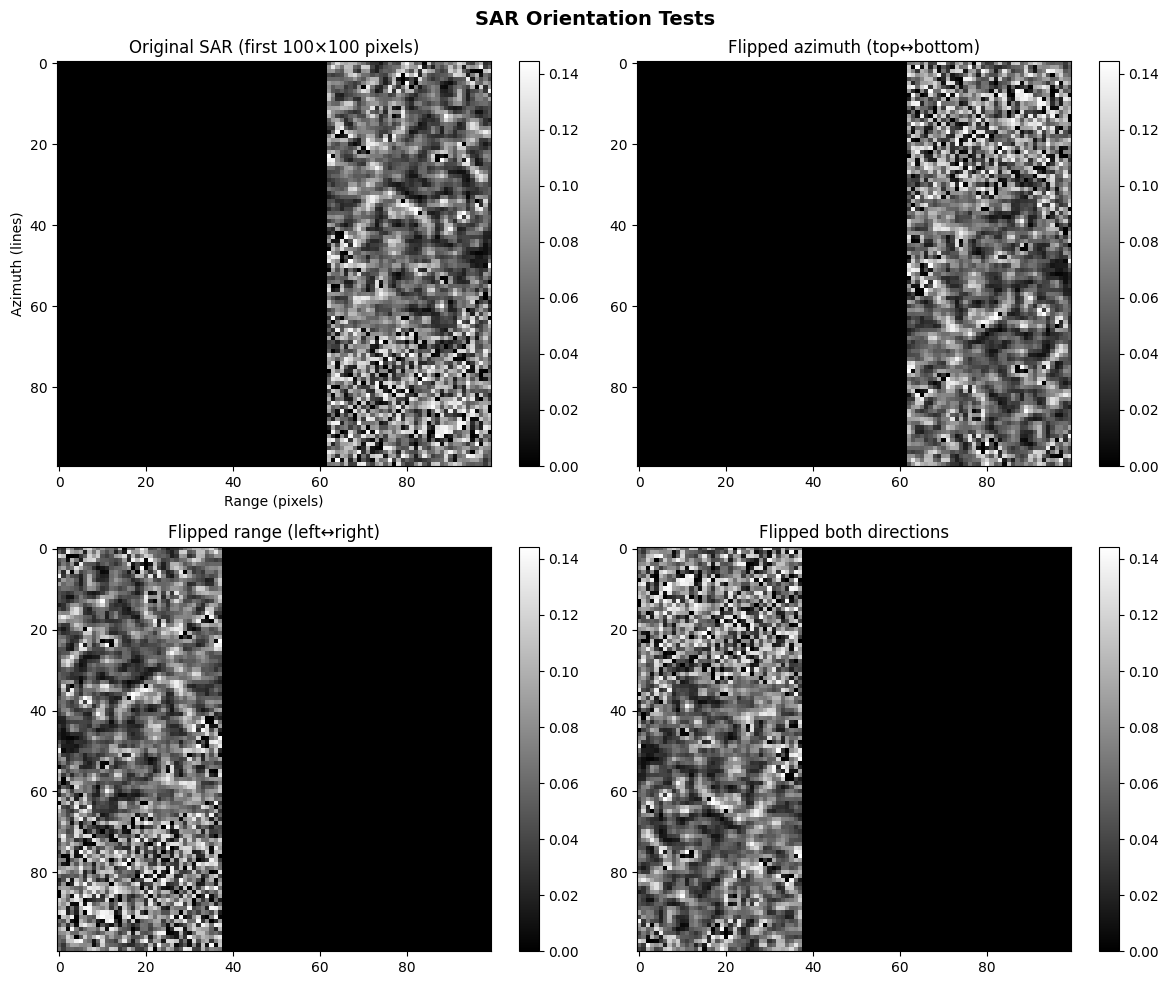


✓ Orientation test saved: sar_orientation_test.png
✓ Recommended: flip_azimuth=False, flip_range=True

FLIPPING SETTINGS
Recommended: flip_azimuth=False, flip_range=True

Modify settings? (Press Enter to accept recommendations, or enter custom values)
Format: 'azimuth range' (e.g., 'True False' or '1 0')
Invalid input. Using recommendations.

Final settings: flip_azimuth=False, flip_range=True
COMPLETE TERRAIN CORRECTION IN LAT/LON COORDINATES
Input SAR shape: 16677×26061
Total pixels: 434,619,297
Flipping - Azimuth: False, Range: True

[1/6] Parsing sparse geolocation grid...
  Sparse grid shape: (10, 21)
  Sparse grid lines: [   0. 2002. 4004.]...[14014. 16016. 16676.]
  Sparse grid pixels: [   0. 1303. 2606.]...[23454. 24757. 26060.]
  Flipped geolocation grid in range direction
  Latitude range: 38.0669° to 39.9700°
  Longitude range: -2.9291° to 0.3723°

[2/6] Downloading DEM (WGS84 lat/lon)...


Reading tile imagery: 100%|██████████| 19/19 [00:44<00:00,  2.33s/it]


  DEM downloaded: (8222, 14263)
  DEM CRS: EPSG:4326
  DEM resolution: 0.000278° x 0.000278°
  DEM bounds: (-3.2592°, 37.8766°) to (0.7024°, 40.1603°)

[3/6] Creating coordinate interpolators...

[4/6] Processing SAR data in chunks...
  Processing 84 chunks
  Points per chunk: 5,212,200
  Chunk 1/84: lines 0-200
  Chunk 51/84: lines 10000-10200
  Chunk 84/84: lines 16600-16677

[5/6] Combining all processed data...
  Total valid points: 434,619,297
  VV: 434,619,297 values
  VH: 434,619,297 values

[6/6] Creating output grid and interpolating...
  Output grid: 1058×1835 pixels
  Output dimensions: 1,941,430 pixels
  Lat range: 38.065910° to 39.970968° (north-up)
  Lon range: -2.930052° to 0.373301° (east-right)
  Grid spacing: Lat: 0.001802° (200.6m)
                Lon: 0.001801° (200.5m at equator)
  Building KDTree for interpolation...
  Interpolating 1,941,430 points in 4 batches...
    Batch 1/4: 500,000/1,941,430 points
    Batch 4/4: 1,941,430/1,941,430 points
  Interpolating VV

In [27]:
import numpy as np
import xarray as xr
from scipy.interpolate import RectBivariateSpline
from scipy.spatial import cKDTree
from dem_stitcher import stitch_dem
from rasterio.transform import from_bounds, rowcol
import xml.etree.ElementTree as ET
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

def parse_geolocation_grid(annotation_path):
    """Parse sparse geolocation grid from Sentinel-1 annotation XML."""
    tree = ET.parse(annotation_path)
    root = tree.getroot()
    
    # Find all geolocation grid points
    points = []
    for point in root.findall(".//geolocationGridPoint"):
        points.append({
            'line': float(point.find("line").text),
            'pixel': float(point.find("pixel").text),
            'latitude': float(point.find("latitude").text),
            'longitude': float(point.find("longitude").text),
            'height': float(point.find("height").text)
        })
    
    # Organize into grid (typically 10x21 for Sentinel-1)
    lines = sorted(set(p['line'] for p in points))
    pixels = sorted(set(p['pixel'] for p in points))
    
    lat_grid = np.zeros((len(lines), len(pixels)))
    lon_grid = np.zeros((len(lines), len(pixels)))
    
    for p in points:
        i = lines.index(p['line'])
        j = pixels.index(p['pixel'])
        lat_grid[i, j] = p['latitude']
        lon_grid[i, j] = p['longitude']
    
    return {
        'latitude': lat_grid,
        'longitude': lon_grid,
        'lines': np.array(lines),
        'pixels': np.array(pixels)
    }

def terrain_correct_full_data_latlon(ds, annotation_path, 
                                    output_resolution_deg=0.0018,
                                    flip_azimuth=True,
                                    flip_range=True):
    """
    Complete terrain correction for FULL data in lat/lon coordinates.
    Correctly handles SAR orientation (often needs flipping).
    
    Parameters:
    -----------
    flip_azimuth : bool
        Flip in azimuth direction (lines). Usually True for descending orbits.
    flip_range : bool
        Flip in range direction (pixels). Usually True for right-looking SAR.
    """
    print("=" * 80)
    print("COMPLETE TERRAIN CORRECTION IN LAT/LON COORDINATES")
    print("=" * 80)
    print(f"Input SAR shape: {ds.dims['line']}×{ds.dims['pixel']}")
    print(f"Total pixels: {ds.dims['line'] * ds.dims['pixel']:,}")
    print(f"Flipping - Azimuth: {flip_azimuth}, Range: {flip_range}")
    start_time = datetime.now()
    
    # Apply flipping to SAR data if needed
    sar_data = {}
    for band in ds.data_vars:
        data = ds[band].values.copy()
        if flip_azimuth:
            data = np.flipud(data)  # Flip lines (azimuth)
        if flip_range:
            data = np.fliplr(data)  # Flip pixels (range)
        sar_data[band] = data
    
    # 1. Parse sparse geolocation grid
    print("\n[1/6] Parsing sparse geolocation grid...")
    geo_grid = parse_geolocation_grid(annotation_path)
    lat_sparse = geo_grid['latitude']
    lon_sparse = geo_grid['longitude']
    
    # IMPORTANT: Check if we need to flip the geolocation grid too
    # Sentinel-1 geolocation grids are typically in SAR geometry
    # If we flip the SAR data, we may need to flip the geolocation grid too
    print(f"  Sparse grid shape: {lat_sparse.shape}")
    print(f"  Sparse grid lines: {geo_grid['lines'][:3]}...{geo_grid['lines'][-3:]}")
    print(f"  Sparse grid pixels: {geo_grid['pixels'][:3]}...{geo_grid['pixels'][-3:]}")
    
    # Determine if geolocation grid needs flipping
    # Typically, lines increase with azimuth time, pixels increase with range
    if flip_azimuth:
        lat_sparse = np.flipud(lat_sparse)
        lon_sparse = np.flipud(lon_sparse)
        geo_grid['lines'] = np.flip(geo_grid['lines'])
        print("  Flipped geolocation grid in azimuth direction")
    
    if flip_range:
        lat_sparse = np.fliplr(lat_sparse)
        lon_sparse = np.fliplr(lon_sparse)
        geo_grid['pixels'] = np.flip(geo_grid['pixels'])
        print("  Flipped geolocation grid in range direction")
    
    print(f"  Latitude range: {lat_sparse.min():.4f}° to {lat_sparse.max():.4f}°")
    print(f"  Longitude range: {lon_sparse.min():.4f}° to {lon_sparse.max():.4f}°")
    
    # 2. Download DEM for the area (in WGS84 lat/lon)
    print("\n[2/6] Downloading DEM (WGS84 lat/lon)...")
    bounds = [lon_sparse.min(), lat_sparse.min(),
              lon_sparse.max(), lat_sparse.max()]
    
    # Add 10% buffer
    lon_range = lon_sparse.max() - lon_sparse.min()
    lat_range = lat_sparse.max() - lat_sparse.min()
    bounds = [
        lon_sparse.min() - lon_range * 0.1,
        lat_sparse.min() - lat_range * 0.1,
        lon_sparse.max() + lon_range * 0.1,
        lat_sparse.max() + lat_range * 0.1
    ]
    
    try:
        # DEM will be in WGS84 (EPSG:4326)
        dem_data, dem_profile = stitch_dem(
            bounds=bounds, 
            dem_name="glo_30",
            dst_ellipsoidal_height=False  # Get orthometric height
        )
        
        print(f"  DEM downloaded: {dem_data.shape}")
        print(f"  DEM CRS: {dem_profile['crs']}")
        
        # Get DEM transform properly
        if 'transform' not in dem_profile or dem_profile['transform'] is None:
            # Create transform from bounds and shape
            dem_profile['transform'] = from_bounds(
                bounds[0], bounds[1], bounds[2], bounds[3],
                dem_data.shape[1], dem_data.shape[0]
            )
        
        dem_transform = dem_profile['transform']
        dem_res_x = dem_transform.a
        dem_res_y = -dem_transform.e  # Note: transform.e is negative
        print(f"  DEM resolution: {dem_res_x:.6f}° x {dem_res_y:.6f}°")
        print(f"  DEM bounds: ({bounds[0]:.4f}°, {bounds[1]:.4f}°) to "
              f"({bounds[2]:.4f}°, {bounds[3]:.4f}°)")
        
    except Exception as e:
        print(f"  WARNING: Could not download DEM: {e}")
        print("  Using zero elevation (ellipsoid correction)")
        # Create a simple DEM with zero elevation
        dem_data = np.zeros((100, 100), dtype=np.float32)
        dem_profile = {
            'transform': from_bounds(*bounds, 100, 100),
            'crs': 'EPSG:4326'  # WGS84
        }
    
    # 3. Create interpolators from sparse grid
    print("\n[3/6] Creating coordinate interpolators...")
    n_sparse_lines, n_sparse_pixels = lat_sparse.shape
    n_sar_lines, n_sar_pixels = ds.dims['line'], ds.dims['pixel']
    
    # Sparse grid indices in SAR coordinates (after flipping)
    sparse_line_indices = np.linspace(0, n_sar_lines - 1, n_sparse_lines)
    sparse_pixel_indices = np.linspace(0, n_sar_pixels - 1, n_sparse_pixels)
    
    # Create bilinear interpolators
    lat_interp = RectBivariateSpline(sparse_line_indices, sparse_pixel_indices,
                                     lat_sparse, kx=1, ky=1)
    lon_interp = RectBivariateSpline(sparse_line_indices, sparse_pixel_indices,
                                     lon_sparse, kx=1, ky=1)
    
    # 4. Process in CHUNKS to handle full data
    print("\n[4/6] Processing SAR data in chunks...")
    chunk_size_lines = 200  # Smaller chunks for memory management
    
    # Initialize lists to store processed data
    all_lat = []
    all_lon = []
    all_band_data = {band: [] for band in ds.data_vars}
    
    total_lines = n_sar_lines
    num_chunks = int(np.ceil(total_lines / chunk_size_lines))
    
    print(f"  Processing {num_chunks} chunks")
    print(f"  Points per chunk: {chunk_size_lines * n_sar_pixels:,}")
    
    for chunk_idx in range(num_chunks):
        chunk_start = chunk_idx * chunk_size_lines
        chunk_end = min((chunk_idx + 1) * chunk_size_lines, total_lines)
        chunk_lines = np.arange(chunk_start, chunk_end)
        
        if (chunk_idx % 50 == 0) or (chunk_idx == num_chunks - 1):
            print(f"  Chunk {chunk_idx + 1}/{num_chunks}: lines {chunk_start}-{chunk_end}")
        
        # Get lat/lon for this chunk
        chunk_pixels = np.arange(n_sar_pixels)
        lat_chunk = lat_interp(chunk_lines, chunk_pixels, grid=True)
        lon_chunk = lon_interp(chunk_lines, chunk_pixels, grid=True)
        
        # Get DEM heights for this chunk
        # Process in sub-chunks to avoid memory issues
        sub_chunk_size = 50000
        lat_flat = lat_chunk.ravel()
        lon_flat = lon_chunk.ravel()
        heights_flat = np.zeros_like(lat_flat, dtype=np.float32)
        
        for sub_start in range(0, len(lat_flat), sub_chunk_size):
            sub_end = min(sub_start + sub_chunk_size, len(lat_flat))
            
            rows, cols = rowcol(dem_profile['transform'], 
                               lon_flat[sub_start:sub_end], 
                               lat_flat[sub_start:sub_end])
            
            rows = np.clip(rows, 0, dem_data.shape[0] - 1)
            cols = np.clip(cols, 0, dem_data.shape[1] - 1)
            
            heights_flat[sub_start:sub_end] = dem_data[rows, cols]
        
        # Store valid lat/lon coordinates
        valid_mask = np.isfinite(lat_flat) & np.isfinite(lon_flat) & np.isfinite(heights_flat)
        
        if np.any(valid_mask):
            all_lat.append(lat_flat[valid_mask])
            all_lon.append(lon_flat[valid_mask])
        
        # Store band data for this chunk (already flipped if needed)
        for band in ds.data_vars:
            band_chunk = sar_data[band][chunk_start:chunk_end, :]
            band_flat = band_chunk.ravel()
            all_band_data[band].append(band_flat[valid_mask])
        
        # Clear memory
        del lat_chunk, lon_chunk, lat_flat, lon_flat, heights_flat
        if 'band_flat' in locals():
            del band_flat
    
    # Combine all chunks
    print("\n[5/6] Combining all processed data...")
    lat_all = np.concatenate(all_lat) if all_lat else np.array([])
    lon_all = np.concatenate(all_lon) if all_lon else np.array([])
    
    if len(lat_all) == 0:
        raise ValueError("No valid coordinates found!")
    
    print(f"  Total valid points: {len(lat_all):,}")
    
    # Combine band data
    band_data_all = {}
    for band in ds.data_vars:
        band_data_all[band] = np.concatenate(all_band_data[band])
        print(f"  {band}: {band_data_all[band].size:,} values")
    
    # 5. Create output grid in lat/lon
    print("\n[6/6] Creating output grid and interpolating...")
    
    # Determine output bounds (with small buffer)
    lat_min, lat_max = lat_all.min() - 0.001, lat_all.max() + 0.001
    lon_min, lon_max = lon_all.min() - 0.001, lon_all.max() + 0.001
    
    # Calculate output grid dimensions based on resolution
    output_width = int((lon_max - lon_min) / output_resolution_deg)
    output_height = int((lat_max - lat_min) / output_resolution_deg)
    
    # Ensure reasonable grid size
    output_width = max(output_width, 10)
    output_height = max(output_height, 10)
    
    # Create output grid (latitude increases northward, longitude increases eastward)
    lat_out = np.linspace(lat_max, lat_min, output_height)  # Note: lat_max to lat_min for north-up
    lon_out = np.linspace(lon_min, lon_max, output_width)   # lon_min to lon_max for east-right
    
    print(f"  Output grid: {output_height}×{output_width} pixels")
    print(f"  Output dimensions: {output_height*output_width:,} pixels")
    print(f"  Lat range: {lat_min:.6f}° to {lat_max:.6f}° (north-up)")
    print(f"  Lon range: {lon_min:.6f}° to {lon_max:.6f}° (east-right)")
    print(f"  Grid spacing: Lat: {abs(lat_out[1]-lat_out[0]):.6f}° "
          f"({abs(lat_out[1]-lat_out[0])*111320:.1f}m)")
    print(f"                Lon: {lon_out[1]-lon_out[0]:.6f}° "
          f"({(lon_out[1]-lon_out[0])*111320:.1f}m at equator)")
    
    # Build KDTree for fast nearest neighbor interpolation
    print("  Building KDTree for interpolation...")
    source_points = np.column_stack([lat_all, lon_all])
    tree = cKDTree(source_points)
    
    # Create target grid and query in smaller blocks
    lat_grid, lon_grid = np.meshgrid(lat_out, lon_out, indexing='ij')
    target_points = np.column_stack([lat_grid.ravel(), lon_grid.ravel()])
    
    batch_size = 500000
    all_indices = []
    
    num_batches = int(np.ceil(len(target_points) / batch_size))
    print(f"  Interpolating {len(target_points):,} points in {num_batches} batches...")
    
    for i in range(0, len(target_points), batch_size):
        batch_end = min(i + batch_size, len(target_points))
        _, indices = tree.query(target_points[i:batch_end], k=1, workers=4)
        all_indices.append(indices)
        
        if (i // batch_size) % 10 == 0 or batch_end == len(target_points):
            print(f"    Batch {i//batch_size + 1}/{num_batches}: "
                  f"{batch_end:,}/{len(target_points):,} points")
    
    indices_all = np.concatenate(all_indices)
    
    # Interpolate each band
    corrected_bands = {}
    
    for band in ds.data_vars:
        print(f"  Interpolating {band}...")
        band_values = band_data_all[band]
        
        # Map values using nearest neighbor
        corrected_band = band_values[indices_all].reshape(output_height, output_width)
        
        # Create DataArray with proper orientation
        corrected_bands[band] = xr.DataArray(
            corrected_band,
            dims=['latitude', 'longitude'],
            coords={
                'latitude': lat_out,  # Already north-up
                'longitude': lon_out  # Already east-right
            },
            attrs={
                'long_name': f'Terrain-corrected {band}',
                'units': 'backscatter coefficient',
                'grid_mapping': 'crs',
                'coordinates': 'latitude longitude',
                'orientation': 'north-up',
                'flipped_azimuth': flip_azimuth,
                'flipped_range': flip_range
            }
        )
    
    # Create final dataset
    result = xr.Dataset(corrected_bands)
    
    # Add coordinate reference system (WGS84)
    result.attrs['crs'] = 'EPSG:4326'
    result.attrs['geospatial_bounds'] = f'{lon_min:.6f},{lat_min:.6f},{lon_max:.6f},{lat_max:.6f}'
    result.attrs['geospatial_lat_units'] = 'degrees_north'
    result.attrs['geospatial_lon_units'] = 'degrees_east'
    result.attrs['geospatial_lat_resolution'] = float(abs(lat_out[1] - lat_out[0]))
    result.attrs['geospatial_lon_resolution'] = float(lon_out[1] - lon_out[0])
    
    # Add processing metadata
    processing_time = (datetime.now() - start_time).total_seconds()
    result.attrs.update({
        'title': 'Sentinel-1 Terrain Corrected SAR Data (WGS84 lat/lon)',
        'processing_date': datetime.now().isoformat(),
        'processing_time_seconds': processing_time,
        'processing_method': 'bilinear_interpolation_with_DEM',
        'dem_source': 'glo_30',
        'sar_orientation_correction': f'azimuth_flip={flip_azimuth}, range_flip={flip_range}',
        'output_resolution_degrees': float(output_resolution_deg),
        'output_resolution_meters_approx': float(output_resolution_deg * 111320),
        'output_crs': 'EPSG:4326',
        'input_dimensions': f"{n_sar_lines}x{n_sar_pixels}",
        'output_dimensions': f"{output_height}x{output_width}",
        'orientation_note': 'North-up (latitude decreasing with row index)',
        'software': 'SAR Terrain Correction Processor'
    })
    
    print("\n" + "=" * 80)
    print("✅ TERRAIN CORRECTION COMPLETED SUCCESSFULLY!")
    print("=" * 80)
    print(f"Total processing time: {processing_time:.1f} seconds ({processing_time/60:.1f} minutes)")
    print(f"Output grid: {output_height}×{output_width} pixels")
    print(f"Orientation: North-up (latitude decreases with row index)")
    print(f"Flipping applied: Azimuth={flip_azimuth}, Range={flip_range}")
    
    return result

# ----------------------------------------------------------------------
# QUICK TEST FUNCTION WITH ORIENTATION CHECK
# ----------------------------------------------------------------------

def quick_orientation_test(ds, annotation_path):
    """
    Quick test to check SAR orientation and determine correct flipping.
    """
    print("=" * 80)
    print("SAR ORIENTATION TEST")
    print("=" * 80)
    
    # Parse geolocation grid
    geo_grid = parse_geolocation_grid(annotation_path)
    lat_grid = geo_grid['latitude']
    lon_grid = geo_grid['longitude']
    
    print("Original geolocation grid corners:")
    print(f"  Top-left:     ({lat_grid[0, 0]:.4f}°, {lon_grid[0, 0]:.4f}°)")
    print(f"  Top-right:    ({lat_grid[0, -1]:.4f}°, {lon_grid[0, -1]:.4f}°)")
    print(f"  Bottom-left:  ({lat_grid[-1, 0]:.4f}°, {lon_grid[-1, 0]:.4f}°)")
    print(f"  Bottom-right: ({lat_grid[-1, -1]:.4f}°, {lon_grid[-1, -1]:.4f}°)")
    
    # Check if latitude increases or decreases with line index
    lat_change = lat_grid[-1, 0] - lat_grid[0, 0]
    lon_change = lon_grid[-1, 0] - lon_grid[0, 0]
    
    print(f"\nLatitude change from first to last line: {lat_change:.4f}°")
    print(f"Longitude change from first to last line: {lon_change:.4f}°")
    
    # Typical Sentinel-1 patterns:
    # - Ascending orbit: latitude increases with line
    # - Descending orbit: latitude decreases with line
    # - Right-looking: near range (small pixel index) is to the right
    
    print("\nTypical SAR patterns:")
    print("- Ascending orbit: Northward movement, latitude increases with time")
    print("- Descending orbit: Southward movement, latitude decreases with time")
    print("- Right-looking: Near range to the right (east for descending)")
    
    # Check a few SAR data values
    first_band = list(ds.data_vars.keys())[0]
    sar_data = ds[first_band].values
    
    print(f"\nSAR data shape: {sar_data.shape}")
    print(f"SAR data corners:")
    print(f"  Top-left:     {sar_data[0, 0]:.3f}")
    print(f"  Top-right:    {sar_data[0, -1]:.3f}")
    print(f"  Bottom-left:  {sar_data[-1, 0]:.3f}")
    print(f"  Bottom-right: {sar_data[-1, -1]:.3f}")
    
    # Simple test: compare top and bottom edges
    top_edge_mean = np.nanmean(sar_data[0, :])
    bottom_edge_mean = np.nanmean(sar_data[-1, :])
    left_edge_mean = np.nanmean(sar_data[:, 0])
    right_edge_mean = np.nanmean(sar_data[:, -1])
    
    print(f"\nEdge means:")
    print(f"  Top edge:    {top_edge_mean:.3f}")
    print(f"  Bottom edge: {bottom_edge_mean:.3f}")
    print(f"  Left edge:   {left_edge_mean:.3f}")
    print(f"  Right edge:  {right_edge_mean:.3f}")
    
    # Try to infer orientation
    print("\n" + "=" * 80)
    print("RECOMMENDED FLIPPING SETTINGS:")
    print("=" * 80)
    
    # Check orbit direction from filename or coordinates
    annotation_path_lower = annotation_path.lower()
    if 'asc' in annotation_path_lower:
        print("Based on filename: ASCENDING orbit detected")
        print("  Try: flip_azimuth=False, flip_range=True")
        recommendations = (False, True)
    elif 'dsc' in annotation_path_lower or 'desc' in annotation_path_lower:
        print("Based on filename: DESCENDING orbit detected")
        print("  Try: flip_azimuth=True, flip_range=True")
        recommendations = (True, True)
    else:
        # Guess based on latitude change
        if lat_change > 0:
            print("Based on latitude change: Likely ASCENDING orbit")
            print("  Try: flip_azimuth=False, flip_range=True")
            recommendations = (False, True)
        else:
            print("Based on latitude change: Likely DESCENDING orbit")
            print("  Try: flip_azimuth=True, flip_range=True")
            recommendations = (True, True)
    
    print("\nQuick visualization to check orientation...")
    import matplotlib.pyplot as plt
    
    # Create a small visualization
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Original SAR
    ax1 = axes[0, 0]
    im1 = ax1.imshow(sar_data[:100, :100], cmap='gray', aspect='auto')
    ax1.set_title('Original SAR (first 100×100 pixels)')
    ax1.set_xlabel('Range (pixels)')
    ax1.set_ylabel('Azimuth (lines)')
    plt.colorbar(im1, ax=ax1)
    
    # Flipped versions
    ax2 = axes[0, 1]
    sar_flipped_az = np.flipud(sar_data[:100, :100])
    im2 = ax2.imshow(sar_flipped_az, cmap='gray', aspect='auto')
    ax2.set_title('Flipped azimuth (top↔bottom)')
    plt.colorbar(im2, ax=ax2)
    
    ax3 = axes[1, 0]
    sar_flipped_rg = np.fliplr(sar_data[:100, :100])
    im3 = ax3.imshow(sar_flipped_rg, cmap='gray', aspect='auto')
    ax3.set_title('Flipped range (left↔right)')
    plt.colorbar(im3, ax=ax3)
    
    ax4 = axes[1, 1]
    sar_flipped_both = np.flipud(np.fliplr(sar_data[:100, :100]))
    im4 = ax4.imshow(sar_flipped_both, cmap='gray', aspect='auto')
    ax4.set_title('Flipped both directions')
    plt.colorbar(im4, ax=ax4)
    
    plt.suptitle('SAR Orientation Tests', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('sar_orientation_test.png', dpi=120, bbox_inches='tight')
    plt.show()
    
    print(f"\n✓ Orientation test saved: sar_orientation_test.png")
    print(f"✓ Recommended: flip_azimuth={recommendations[0]}, flip_range={recommendations[1]}")
    
    return recommendations

# ----------------------------------------------------------------------
# MAIN EXECUTION
# ----------------------------------------------------------------------

def main():
    """Main execution with orientation handling."""
    annotation_xml_path = "docs/data/S1A_IW_GRDH_1SDV_20241007T180256_20241007T180321_056000_06D943_D46B.SAFE/annotation/s1a-iw-grd-vv-20241007t180256-20241007t180321-056000-06d943-001.xml"
    
    print("=" * 80)
    print("SAR TERRAIN CORRECTION WITH ORIENTATION HANDLING")
    print("=" * 80)
    
    # First, run orientation test
    print("\nRunning orientation test...")
    flip_azimuth, flip_range = quick_orientation_test(filtered_ds, annotation_xml_path)
    
    # Ask user to confirm or modify
    print("\n" + "=" * 80)
    print("FLIPPING SETTINGS")
    print("=" * 80)
    print(f"Recommended: flip_azimuth={flip_azimuth}, flip_range={flip_range}")
    print("\nModify settings? (Press Enter to accept recommendations, or enter custom values)")
    print("Format: 'azimuth range' (e.g., 'True False' or '1 0')")
    
    user_input = input("Your choice: ").strip()
    
    if user_input:
        try:
            az_val, rg_val = user_input.split()
            flip_azimuth = az_val.lower() in ['true', '1', 'yes', 'y']
            flip_range = rg_val.lower() in ['true', '1', 'yes', 'y']
        except:
            print("Invalid input. Using recommendations.")
    
    print(f"\nFinal settings: flip_azimuth={flip_azimuth}, flip_range={flip_range}")
    
    # Run terrain correction with specified flipping
    result = terrain_correct_full_data_latlon(
        ds=filtered_ds,
        annotation_path=annotation_xml_path,
        output_resolution_deg=0.0018,  # ~200m
        flip_azimuth=flip_azimuth,
        flip_range=flip_range
    )
    
    # # Export
    # from your_export_code import export_geotiff_latlon
    # export_geotiff_latlon(result, "terrain_corrected_oriented.tif")
    
    return result

if __name__ == "__main__":
    try:
        result = main()
        print("\n🎉 Processing completed with proper orientation!")
    except Exception as e:
        print(f"\n❌ Error: {e}")
        import traceback
        traceback.print_exc()

In [28]:
result

<xarray.Dataset> Size: 31MB
Dimensions:    (latitude: 1058, longitude: 1835)
Coordinates:
  * latitude   (latitude) float64 8kB 39.97 39.97 39.97 ... 38.07 38.07 38.07
  * longitude  (longitude) float64 15kB -2.93 -2.928 -2.926 ... 0.3715 0.3733
Data variables:
    VV         (latitude, longitude) float64 16MB 0.1006 0.09207 ... 0.0 0.0
    VH         (latitude, longitude) float64 16MB 0.04036 0.02508 ... 0.0 0.0
Attributes: (12/19)
    crs:                              EPSG:4326
    geospatial_bounds:                -2.930052,38.065910,0.373301,39.970968
    geospatial_lat_units:             degrees_north
    geospatial_lon_units:             degrees_east
    geospatial_lat_resolution:        0.0018023246489491385
    geospatial_lon_resolution:        0.0018011736625833663
    ...                               ...
    output_resolution_meters_approx:  200.376
    output_crs:                       EPSG:4326
    input_dimensions:                 16677x26061
    output_dimensions:                1058x1835
    orientation_note:                 North-up (latitude decreasing with row ...
    software:                         SAR Terrain Correction Processor

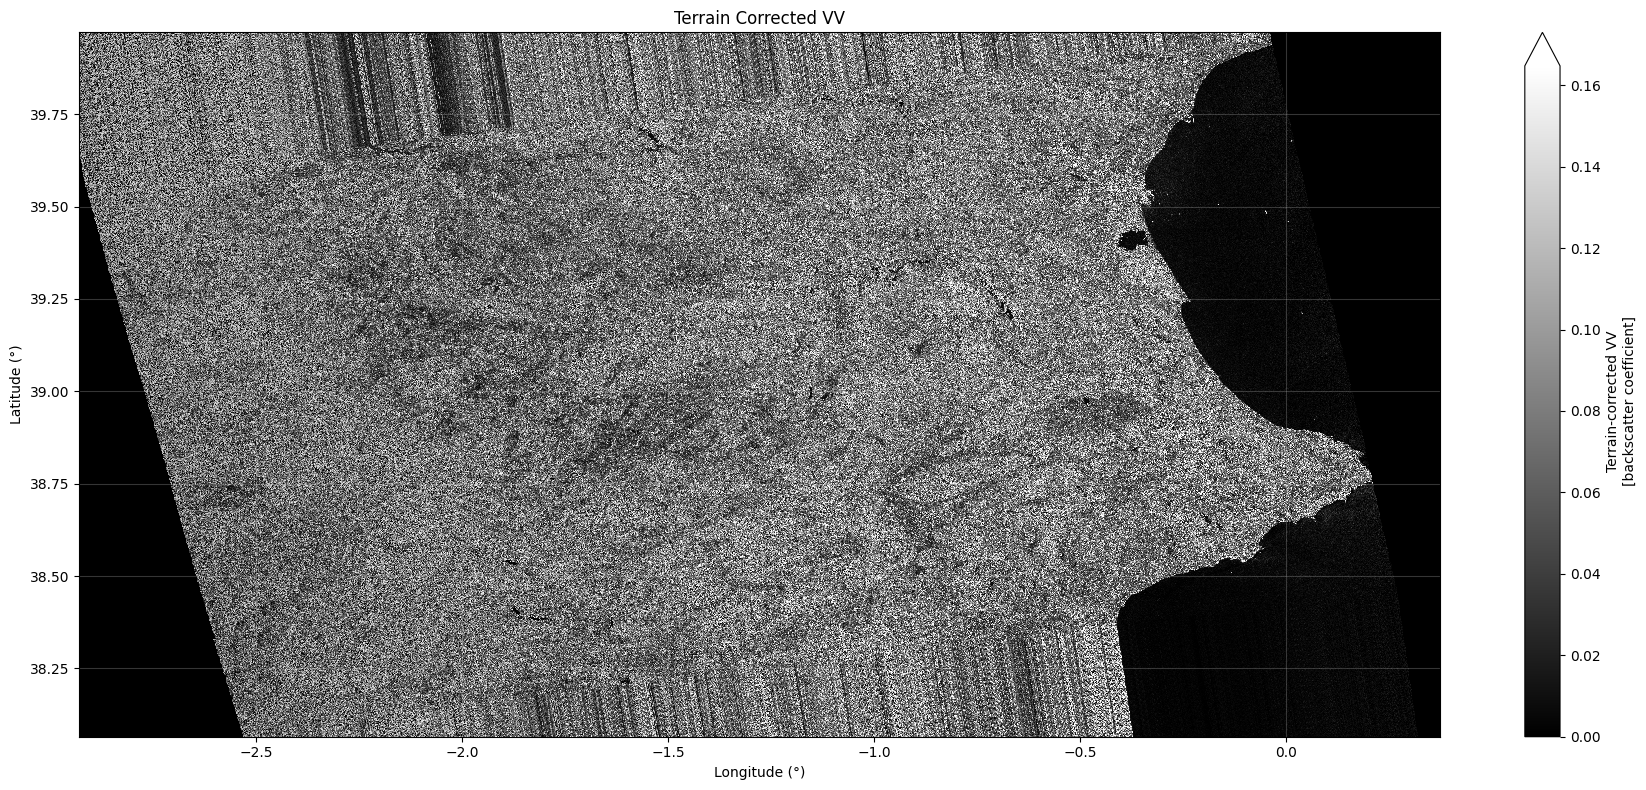

In [34]:
# Quickest visualization (run this immediately after your processing)
def simple_visualize(result):
    """Simplest possible visualization."""
    import matplotlib.pyplot as plt
    
    first_band = list(result.data_vars.keys())[0]
    
    plt.figure(figsize=(18, 8))
    result[first_band].plot(cmap='gray', add_colorbar=True, robust=True)
    plt.title(f'Terrain Corrected {first_band}')
    plt.xlabel('Longitude (°)')
    plt.ylabel('Latitude (°)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('simple_result.png', dpi=150)
    plt.show()

simple_visualize(result)

In [31]:
def export_to_geotiff_rioxarray(result, output_path="terrain_corrected.tif", compress=True):
    """
    Export terrain-corrected dataset to GeoTIFF using rioxarray.
    This is the cleanest and most reliable method.
    """
    print(f"\n📤 Exporting to GeoTIFF: {output_path}")
    
    try:
        import rioxarray
        
        # Check if it's single or multi-band
        bands = list(result.data_vars)
        
        if len(bands) == 1:
            # Single band export
            band_name = bands[0]
            data_array = result[band_name]
            
            print(f"  Exporting single band: {band_name}")
            print(f"  Data shape: {data_array.shape}")
            print(f"  Data type: {data_array.dtype}")
            
            # Rename coordinates to standard names
            data_array = data_array.rename({
                'latitude': 'y',
                'longitude': 'x'
            })
            
            # Set spatial dimensions
            data_array = data_array.rio.set_spatial_dims('x', 'y')
            
            # Write CRS (WGS84)
            data_array = data_array.rio.write_crs('EPSG:4326')
            
            # Export with compression
            data_array.rio.to_raster(
                output_path,
                driver='GTiff',
                compress='LZW' if compress else None,
                dtype=data_array.dtype,
                nodata=np.nan,
                tags=result.attrs
            )
            
            print(f"✓ Single band exported successfully")
            
        else:
            # Multi-band export
            print(f"  Exporting {len(bands)} bands: {', '.join(bands)}")
            
            # Prepare data array with band dimension
            band_arrays = []
            for band in bands:
                band_data = result[band].rename({'latitude': 'y', 'longitude': 'x'})
                band_arrays.append(band_data)
            
            # Create dataset with all bands
            from xarray import DataArray
            
            # Stack bands along new dimension
            stacked_data = np.stack([ba.values for ba in band_arrays], axis=0)
            
            stacked_da = DataArray(
                stacked_data,
                dims=['band', 'y', 'x'],
                coords={
                    'band': bands,
                    'y': result.latitude.values,
                    'x': result.longitude.values
                },
                attrs=result.attrs
            )
            
            # Set spatial dimensions and CRS
            stacked_da = stacked_da.rio.set_spatial_dims('x', 'y')
            stacked_da = stacked_da.rio.write_crs('EPSG:4326')
            
            # Export
            stacked_da.rio.to_raster(
                output_path,
                driver='GTiff',
                compress='LZW' if compress else None,
                dtype=stacked_da.dtype,
                nodata=np.nan,
                tags={'Band_Names': ','.join(bands)}
            )
            
            print(f"✓ {len(bands)} bands exported successfully")
        
        print(f"✓ GeoTIFF saved: {output_path}")
        print(f"✓ CRS: EPSG:4326 (WGS84 lat/lon)")
        
        # Print file info
        import os
        file_size = os.path.getsize(output_path) / (1024*1024)  # MB
        print(f"✓ File size: {file_size:.1f} MB")
        
        return output_path
        
    except ImportError:
        print("❌ rioxarray not installed!")
        print("Install with: pip install rioxarray")
        return None
        
    except Exception as e:
        print(f"❌ Error exporting with rioxarray: {e}")
        return None

In [32]:
export_to_geotiff_rioxarray(result, output_path="terrain_corrected_123.tif")


📤 Exporting to GeoTIFF: terrain_corrected_123.tif
  Exporting 2 bands: VV, VH
✓ 2 bands exported successfully
✓ GeoTIFF saved: terrain_corrected_123.tif
✓ CRS: EPSG:4326 (WGS84 lat/lon)
✓ File size: 31.3 MB


'terrain_corrected_123.tif'